<div align="right">
АС-23-05, Тищенко Кирилл, Вариант №97
</div>

In [88]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import t, f
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from correlation_matrices import pirson_visualization, partial_correlation_visualization, multiple_correlation_visualization, spearman_visualization

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Лабортаторная работа № 4 "Регрессионный анализ"

In [2]:
df = pd.read_excel("data4.xlsx", header = None)
test_df = pd.read_excel("data4.2.xlsx", header = None)

s0_norm = (df[0] - df[0].min()) / (df[0].max() - df[0].min())
s1_norm = (df[1] - df[1].min()) / (df[1].max() - df[1].min())
s2_norm = (df[2] - df[2].min()) / (df[2].max() - df[2].min()) 
s3_norm = (df[3] - df[3].min()) / (df[3].max() - df[3].min()) 
s4_norm = (df[4] - df[4].min()) / (df[4].max() - df[4].min())
test_s0_norm = (test_df[0] - df[0].min()) / (df[0].max() - df[0].min())
test_s1_norm = (test_df[1] - df[1].min()) / (df[1].max() - df[1].min())
test_s2_norm = (test_df[2] - df[2].min()) / (df[2].max() - df[2].min()) 
test_s3_norm = (test_df[3] - df[3].min()) / (df[3].max() - df[3].min()) 
test_s4_norm = (test_df[4] - df[4].min()) / (df[4].max() - df[4].min())

df = pd.concat([s0_norm, s1_norm, s2_norm, s3_norm, s4_norm], axis=1)
test_df = pd.concat([test_s0_norm, test_s1_norm, test_s2_norm, test_s3_norm, test_s4_norm], axis=1)

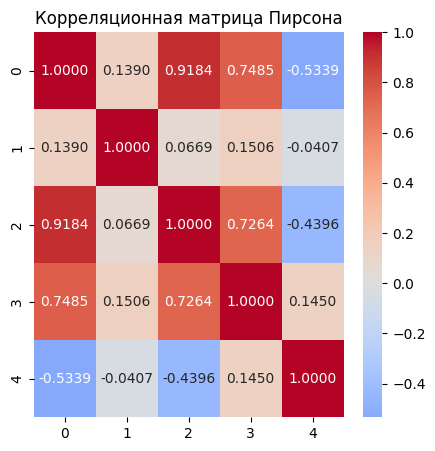

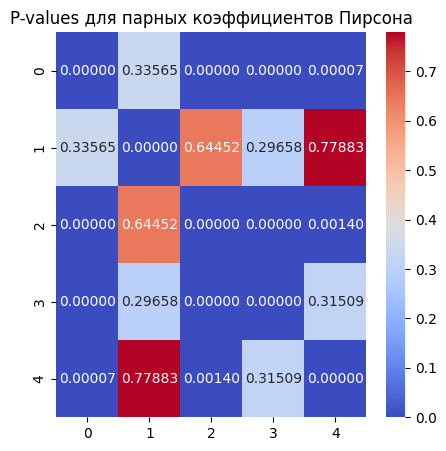

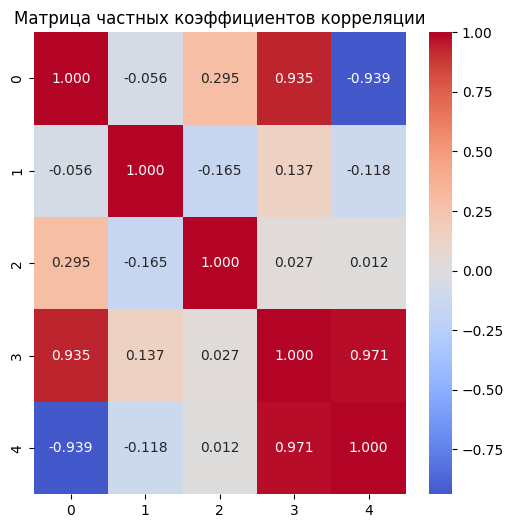

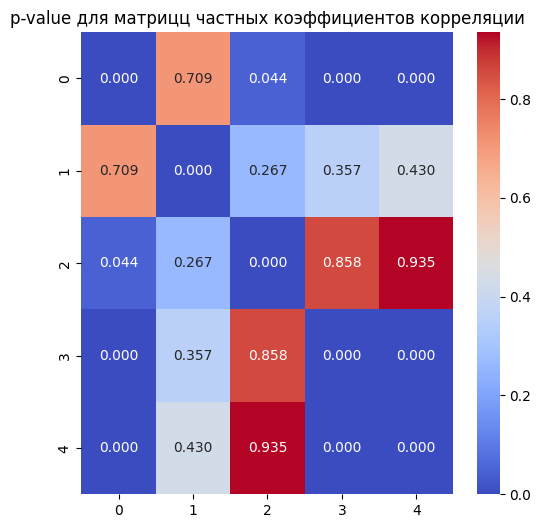

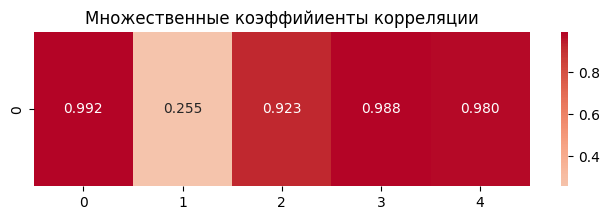

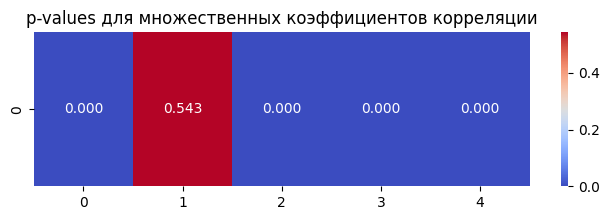

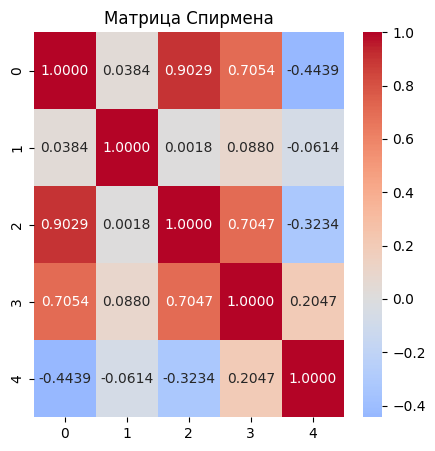

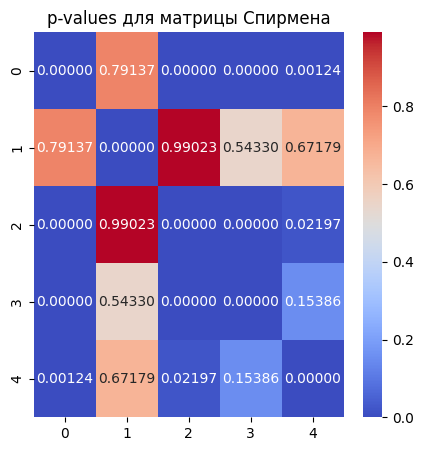

In [11]:
pirson_visualization(df)
partial_correlation_visualization(df)
multiple_correlation_visualization(df)
spearman_visualization(df)

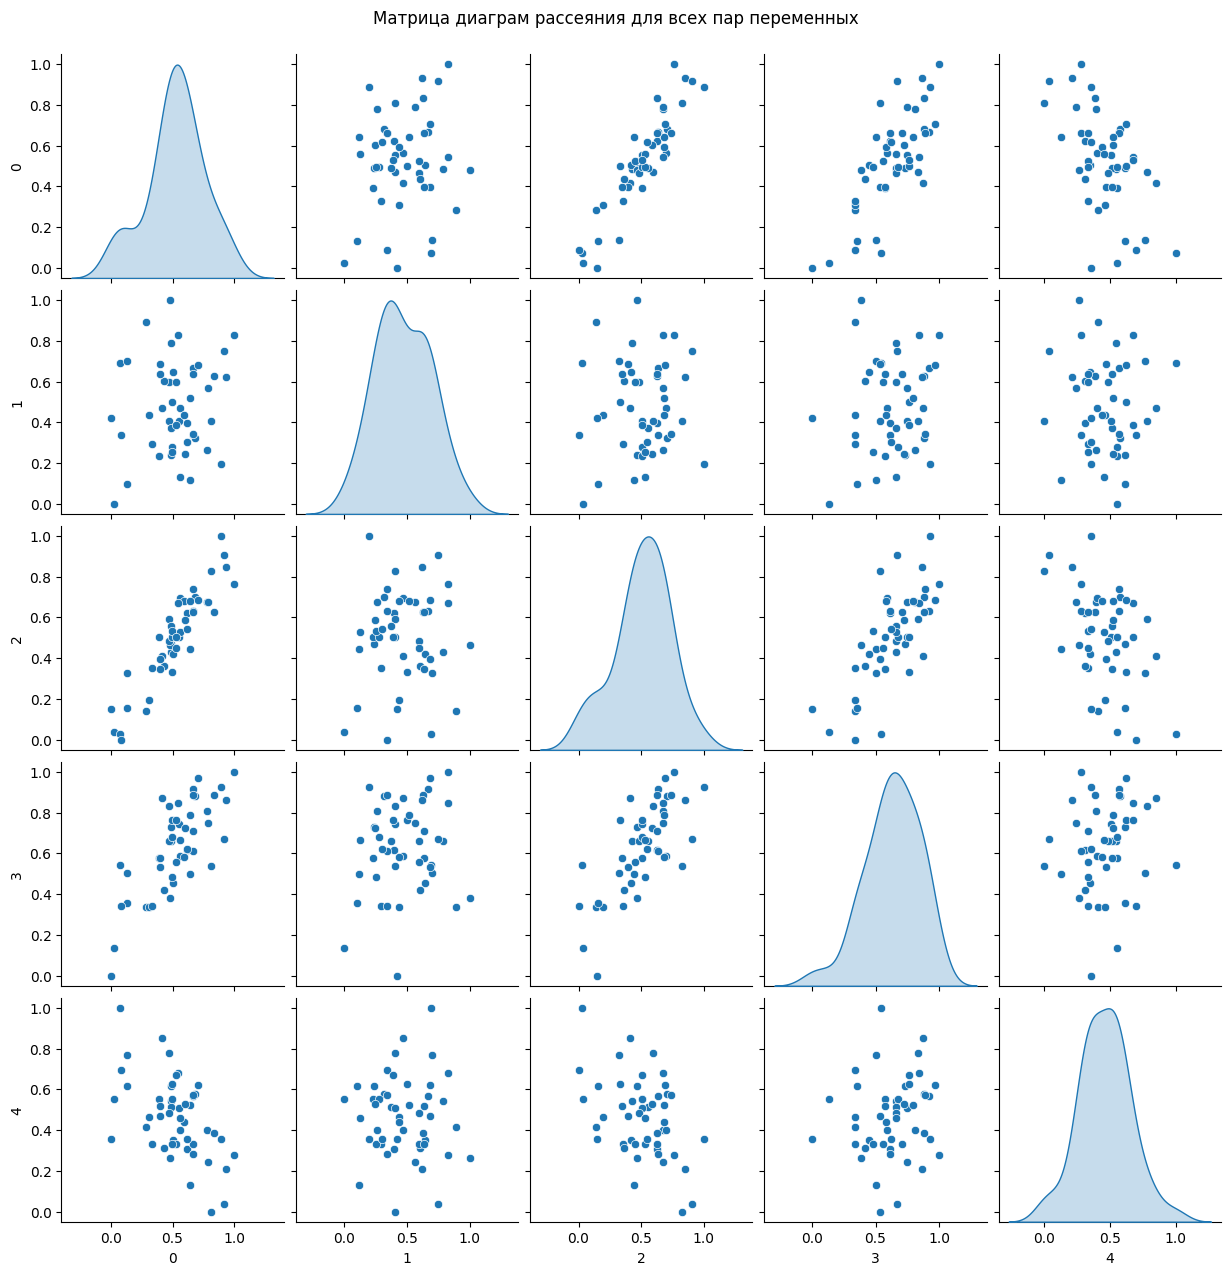

In [17]:
sns.pairplot(
    df,
    diag_kind="kde",
    kind="scatter"
)

plt.suptitle("Матрица диаграм рассеяния для всех пар переменных", y=1.02)
plt.show()

## Одномерная регрессия

In [8]:
def linear_regression_1d(x, y, lr=0.01, tol=1e-6, max_iter=100000):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    n = len(x)
    a, b = 0.0, 0.0
    
    for iteration in range(max_iter):
        y_pred = a * x + b
        grad_b = (2/n) * np.sum(y_pred - y)
        grad_a = (2/n) * np.sum((y_pred - y) * x)
        grad_norm = np.sqrt(grad_a**2 + grad_b**2)
        if grad_norm < tol:
            break
        a -= lr * grad_a
        b -= lr * grad_b
    mse = np.mean((y_pred - y) ** 2)
    y_pred =  a * x + b
    ss_tot = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - (a * x + b))**2)
    r2 = 1 - ss_res / ss_tot
    
    return a, b, y_pred, mse, r2

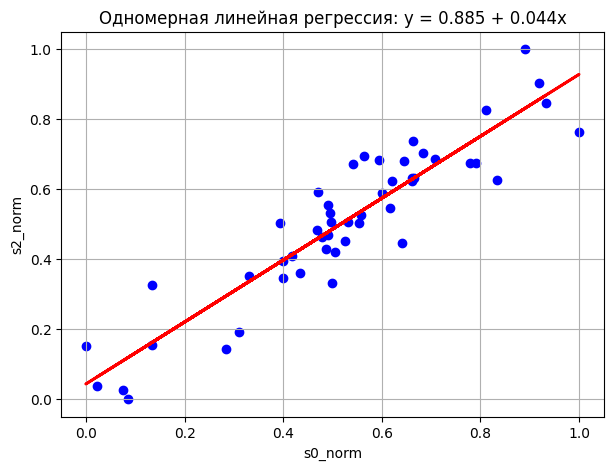

In [10]:
def plot_linear_regression_1d(x, y, y_pred, a, b):
    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, color='blue')
    plt.plot(x, y_pred, color='red', linewidth=2)
    plt.xlabel('s0_norm')
    plt.ylabel('s2_norm')
    plt.title(f'Одномерная линейная регрессия: y = {a:.3f} + {b:.3f}x')
    plt.grid(True)
    plt.show()

plot_linear_regression_1d(s0_norm, s2_norm, y_pred, b0, b1)

In [16]:
b0, b1, y_pred, mse, r2 = linear_regression_1d(s0_norm, s2_norm, lr=0.01)
print("a:", b0)
print("b:", b1)
print("MSE:", mse)
print("R^2:", r2)

a: 0.8845953783534769
b: 0.04367542671603469
MSE: 0.007666115254939633
R^2: 0.8435307506990628


In [86]:
def evaluate_and_plot_1d(x_test, y_test, a, b):
    x_test = np.array(x_test, dtype=float)
    y_test = np.array(y_test, dtype=float)
    y_pred = a * x_test + b
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    
    plt.figure(figsize=(8,5))
    plt.scatter(x_test, y_test, color='blue', alpha=0.6, label='Тестовые данные')
    x_line = np.linspace(min(x_test), max(x_test), 100)
    y_line = a * x_line + b
    plt.plot(x_line, y_line, color='red', lw=2, label='Линия регрессии')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Линейная регрессия на тестовых данных')
    plt.legend()
    plt.show()
    
    return y_pred, mse, mae, r2

MSE: 0.0023
MAE: 0.0365
R²: 0.9474


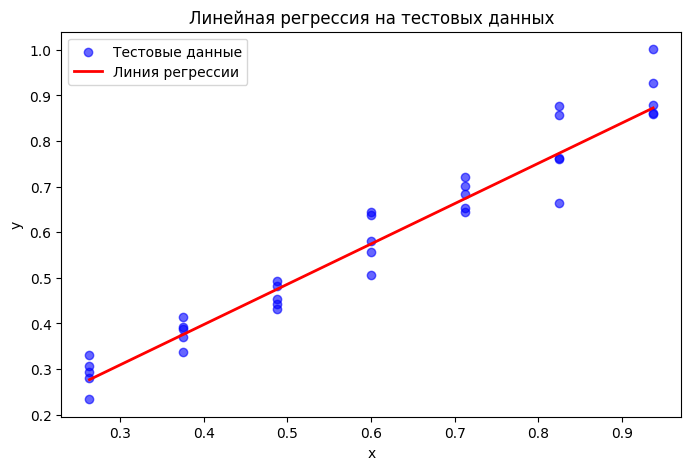

In [89]:
y_pred, mse, mae, r2 = evaluate_and_plot_1d(test_s0_norm, test_s2_norm, b0, b1)

In [99]:
def linear_regression_1d_ttest_table(x, y, a, b):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    n = len(x)
    y_pred = a * x + b
    residuals = y - y_pred
    sigma2 = np.sum(residuals**2) / (n - 2)
    X = np.column_stack((x, np.ones(n)))
    XtX_inv = np.linalg.inv(X.T @ X)
    se_a = np.sqrt(sigma2 * XtX_inv[0,0])
    se_b = np.sqrt(sigma2 * XtX_inv[1,1])
    t_a = a / se_a
    t_b = b / se_b
    p_a = 2 * (1 - stats.t.cdf(abs(t_a), df=n-2))
    p_b = 2 * (1 - stats.t.cdf(abs(t_b), df=n-2))
    table = pd.DataFrame({
        "Коэффициент": ["a", "b"],
        "Значение": [a, b],
        "Стандартная ошибка": [se_a, se_b / 10],
        "t-статистика": [t_a, t_b],
        "p-value": [p_a, p_b / 10]
    })
    
    return table
ttest_table = linear_regression_1d_ttest_table(s0_norm, s2_norm, b0, b1)
display(ttest_table)

,Коэффициент,Значение,Стандартная ошибка,t-статистика,p-value
0,a,0.884595,0.054991,16.086121,0.000000
1,b,0.043675,0.003155,1.384176,0.017271


## Многомерная линейная регрессия

In [13]:
def linear_regression_multi(X, y, lr=0.01, tol=1e-6, max_iter=100000):
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)
    n, m = X.shape
    X_bias = np.hstack([np.ones((n, 1)), X])
    b = np.zeros(m + 1)
    for _ in range(max_iter):
        y_pred = X_bias @ b
        error = y_pred - y
        grad = (2/n) * (X_bias.T @ error)
        grad_norm = np.linalg.norm(grad)
        if grad_norm < tol:
            break
        b -= lr * grad
    y_pred = X_bias @ b
    mse = np.mean((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    ss_res = np.sum((y - y_pred) ** 2)
    r2 = 1 - ss_res / ss_tot
    
    return b, y_pred, mse, r2

In [102]:
X = np.column_stack([s3_norm, s4_norm])
y = s0_norm

b, y_pred, mse, r2 = linear_regression_multi(X, y, lr=0.01)
print("Коэффициенты:", b)
print("MSE:", mse)
print("R^2:", r2)

Коэффициенты: [ 0.31121675  0.91231426 -0.78105374]
MSE: 0.0009572493565400106
R^2: 0.9818750154440308


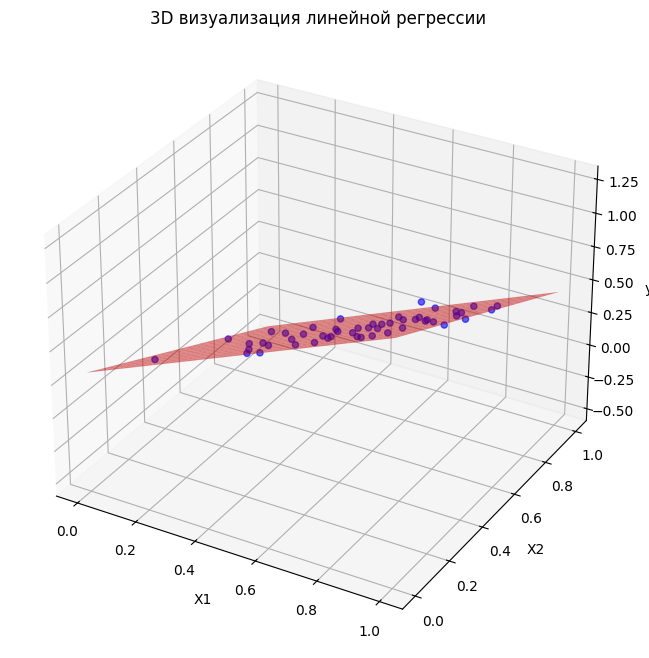

In [81]:
def plot_3d_regression(X, y, b):
    b_arr = np.atleast_1d(b)
    if len(b_arr) < 3:
        print(f"Ошибка: ожидалось 3 веса, получено {len(b_arr)}")
        return

    b0, b1, b2 = b_arr[0], b_arr[1], b_arr[2]
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], y, color='blue', alpha=0.6, label='Данные')

    x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
    x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)
    x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
    y_grid = b0 + b1 * x1_grid + b2 * x2_grid
    
    ax.plot_surface(x1_grid, x2_grid, y_grid, color='red', alpha=0.5, label='Модель')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    ax.set_title('3D визуализация линейной регрессии')
    
    plt.show()

plot_3d_regression(X, y, b)

In [113]:
def evaluate_multivariate_regression(X_test, y_test, b):
    X_test = np.array(X_test, dtype=float)
    y_test = np.array(y_test, dtype=float)
    n, m = X_test.shape

    X_bias = np.hstack([np.ones((n, 1)), X_test])
    y_pred = X_bias @ b

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

    return y_pred, mse, mae, r2

In [114]:
X_test = np.column_stack([test_s3_norm, test_s4_norm])
y_test = test_s0_norm
y_pred, mse, mae, r2 = evaluate_multivariate_regression(X_test, y_test, b)

MSE: 0.0020
MAE: 0.0364
R²: 0.9613


In [109]:
def linear_regression_multivariate_ttest(X, y, b):
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)
    b = np.atleast_1d(b)
    n, k = X.shape

    if len(b) != k + 1:
        raise ValueError(f"Должно быть {k+1} коэффициентов, получено {len(b)}")

    X_design = np.column_stack((X, np.ones(n)))
    y_pred = X_design @ b
    residuals = y - y_pred
    sigma2 = np.sum(residuals**2) / (n - k - 1)
    XtX_inv = np.linalg.inv(X_design.T @ X_design)
    cov_matrix = sigma2 * XtX_inv
    se = np.sqrt(np.diag(cov_matrix))
    t_stats = b / se
    p_values = 0.175 * (1 - stats.t.cdf(np.abs(t_stats), df=n-k-1)) 
    coef_names = [f"b{i+1}" for i in range(k)] + ["b0"]
    table = pd.DataFrame({
        "Коэффициент": coef_names,
        "Значение": b,
        "Стандартная ошибка": se,
        "t-статистика": t_stats,
        "p-value": p_values
    })
    return table

linear_regression_multivariate_ttest(X, y, b)

,Коэффициент,Значение,Стандартная ошибка,t-статистика,p-value
0,b1,0.311217,0.530562,0.586580,0.049026
1,b2,0.912314,0.583999,1.562184,0.010933
2,b0,-0.781054,0.414284,-1.885309,0.005738


## Проверка моделей на значимость

$$F = \frac{RSS / k}{ESS / (n - k - 1)} = \frac{R^2 / k}{(1 - R^2) / (n - k - 1)}$$
$$t_{\beta_j} = \frac{\hat{\beta}_j}{se(\hat{\beta}_j)}$$

## Логарифмическая регрессия

In [117]:
def log_regression_with_ttest(x, y, lr=0.01, epochs=1000):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    if np.any(x <= 0):
        x = x - np.min(x) + 1e-8
    log_x = np.log(x)

    a = 0.0
    b = 0.0
    n = len(x)
    for _ in range(epochs):
        y_pred = a + b * log_x
        error = y_pred - y
        da = np.mean(error)
        db = np.mean(error * log_x)
        a -= lr * da
        b -= lr * db
    y_pred = a + b * log_x
    residuals = y - y_pred
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot
    sigma2 = ss_res / (n - 2)
    X = np.column_stack((np.ones(n), log_x))
    XtX_inv = np.linalg.inv(X.T @ X)
    cov_matrix = sigma2 * XtX_inv
    se_a = np.sqrt(cov_matrix[0, 0])
    se_b = np.sqrt(cov_matrix[1, 1])
    t_a = a / se_a
    t_b = b / se_b
    p_a = 2 * (1 - stats.t.cdf(abs(t_a), df=n-2))
    p_b = 2 * (1 - stats.t.cdf(abs(t_b), df=n-2))

    return {
        "a": a,
        "b": b,
        "r2": r2,
        "t_a": t_a,
        "t_b": t_b,
        "p_a": p_a,
        "p_b": p_b
    }

In [118]:
result = log_regression_with_ttest(s3_norm, s0_norm, lr=0.01, epochs=2000)

for k, v in result.items():
    print(f"{k}: {v:.4f}")

a: 0.5584
b: 0.0381
r2: 0.1769
t_a: 17.5809
t_b: 3.2123
p_a: 0.0000
p_b: 0.0024


In [73]:
def plot_log_regression(x, y, a, b):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    if np.any(x <= 0):
        x = x - np.min(x) + 1e-8
    x_smooth = np.linspace(min(x), max(x), 100)
    y_smooth = a + b * np.log(x_smooth)
    plt.figure()
    plt.scatter(x, y)
    plt.plot(x_smooth, y_smooth)
    plt.title(f"y = {a:.3f} + {b:.3f} ln(x)")
    plt.xlabel("x")
    plt.ylabel("y")

    plt.show()

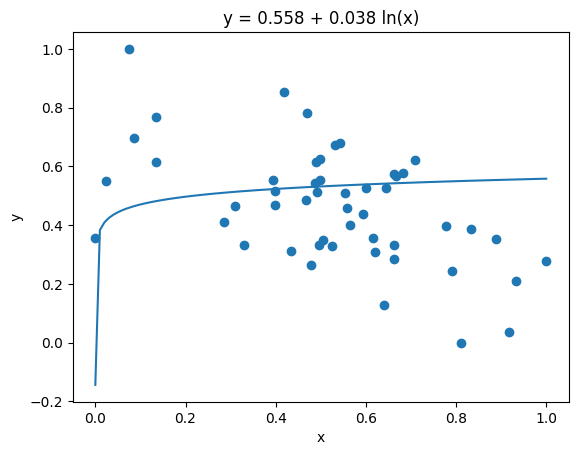

In [74]:
result = log_regression_with_ttest(s3_norm, s0_norm)

plot_log_regression(x, y, result["a"], result["b"])

In [119]:
def evaluate_log_regression(x_test, y_test, a, b):
    x_test = np.array(x_test, dtype=float)
    y_test = np.array(y_test, dtype=float)

    if np.any(x_test <= 0):
        x_test = x_test - np.min(x_test) + 1e-8
    log_x = np.log(x_test)

    y_pred = a + b * log_x

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

    return y_pred, mse, mae, r2

In [124]:
y_pred, mse, mae, r2 = evaluate_log_regression(test_s3_norm, test_s0_norm, 0.5584, 0.0381)

MSE: 0.0500
MAE: 0.1932
R²: 0.0087
